# Control Checks For Context Slot-Support Patterns

Notebook 09 found context-specific slot-support patterns for 5v5 outside-origin offensive-zone shots.

This notebook tests whether those patterns may be explained by basic confounds:

- origin shot location
- defender crowding
- tracking completeness
- first evaluated xG
- sample-size imbalance

The goal is not to prove causality. The goal is to identify whether the diagnostic patterns are robust enough to justify modeling and final exhibit development.

## 1. Setup

Load libraries, define paths, and configure display options.

In [1]:
# Import libraries used for control and sensitivity checks

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Define project paths

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Processed data exists:", DATA_PROCESSED.exists())
print("Figures dir:", FIGURES_DIR)

Project root: c:\Users\rinal\hockey-analytics\outside-shot-value
Processed data exists: True
Figures dir: c:\Users\rinal\hockey-analytics\outside-shot-value\figures


In [3]:
# Configure pandas display options for readable notebook tables

pd.set_option("display.max_columns", 180)
pd.set_option("display.width", 220)
pd.set_option("display.float_format", lambda x: f"{x:0.6f}")

## 2. Load Context-Labeled Dataset

Load the context-labeled origin-shot chain dataset created in Notebook 08.

This dataset contains the context labels analyzed in Notebook 09.

In [4]:
# Load context-labeled origin-shot chain dataset

df = pd.read_parquet(DATA_PROCESSED / "origin_shot_sequences_context_labeled.parquet")

print("df:", df.shape)
df.head()

df: (48673, 111)


,chain_id,game_id,period,sequence_id,team_id,raw_first_chance_team_id,n_team_id_overrides_for_chain,chain_start_time,chain_end_time,chain_duration_seconds,n_chances_in_chain,anchor_origin_event_id,anchor_origin_period_time,anchor_origin_location,anchor_first_chance_event_id,anchor_first_chance_time,anchor_first_event_type,anchor_first_chance_location,first_evaluated_chance_event_id,first_evaluated_chance_time,first_evaluated_event_type,first_evaluated_location,first_evaluated_xg,chain_max_xg,chain_sum_xg,has_deflection,n_deflections,first_deflection_event_id,first_deflection_time,deflection_max_xg,deflection_sum_xg,has_followup_chance,n_followup_chances,first_followup_event_id,first_followup_time,followup_max_xg,followup_sum_xg,chain_goal,chain_goal_event_id,chain_goal_time,chain_goal_player_id,chain_goal_player_name,chain_any_goal_within_2s_flag,origin_tracking_rows,origin_identified_tracking_players,origin_missing_tracking_player_rows,origin_attacker_skaters_tracked,origin_defender_skaters_tracked,observed_origin_attackers_in_slot,observed_origin_defenders_in_slot,origin_goalies_tracked,origin_shooter_tracked,origin_tracking_available,origin_tracking_error_flag,origin_tracking_completeness_bucket,home_team,away_team,home_team_id,away_team_id,team_side,period_time_start,game_stint,period_time_end,n_home_skaters,n_away_skaters,is_home_net_empty,is_away_net_empty,home_score,away_score,origin_time_within_stint,is_5v5,team_n_skaters,opponent_n_skaters,team_net_empty,opponent_net_empty,raw_anchor_origin_period_time,anchor_origin_event_type_raw,anchor_origin_event_team,anchor_origin_x_adj,anchor_origin_y_adj,is_offensive_zone_origin,is_behind_offensive_blue_line_origin,chain_team_name,prior_faceoff_event_id,prior_faceoff_time,prior_faceoff_team,prior_faceoff_x_adj_for_event_team,prior_faceoff_y_adj_for_event_team,seconds_since_prior_faceoff,prior_faceoff_x_adj_for_chain_team,prior_faceoff_y_adj_for_chain_team,has_prior_faceoff_in_sequence,prior_faceoff_within_5s,prior_faceoff_in_offensive_zone_for_chain,oz_faceoff_context_5s,first_same_team_event_time_in_sequence,n_same_team_events_in_sequence,seconds_since_first_same_team_event_in_sequence,early_same_team_sequence_5s_diagnostic,settled_sequence_gt5s_diagnostic,entry_proxy_event_id,entry_proxy_time,entry_proxy_event_type,entry_proxy_x_adj_for_chain_team,entry_proxy_y_adj_for_chain_team,seconds_since_entry_proxy,has_entry_proxy_in_sequence,entry_proxy_within_5s,oz_entry_context_5s_proxy,settled_offensive_zone_context_proxy,shot_context
0,00b0366a-95c6-5250-2dae-e3dd5c4198bc_p1_s11_td...,00b0366a-95c6-5250-2dae-e3dd5c4198bc,1,11,d7ff41e7-8310-f2ab-3c79-6ad3d1f4f019,d7ff41e7-8310-f2ab-3c79-6ad3d1f4f019,0,591.730000,591.730000,0.000000,1,565,591.730000,outside,565,591.730000,shot,outside,565,591.730000,shot,outside,0.040997,0.040997,0.040997,False,0,<NA>,NaN,0.000000,0.000000,False,0,<NA>,NaN,0.000000,0.000000,False,<NA>,NaN,NaN,NaN,False,8,7,1,4,3,1,2,0,True,True,False,partial_observed,GR,CLE,6cac12e2-0546-2c1a-689f-ab26d8a6355a,d7ff41e7-8310-f2ab-3c79-6ad3d1f4f019,away,589.030000,64.000000,605.030000,4.000000,4.000000,False,False,1.000000,1.000000,True,False,4.000000,4.000000,False,False,591.730000000,shot,CLE,32.889107,25.397057,True,False,CLE,558.000000,589.030000,CLE,69.104380,21.376137,2.700000,69.104380,21.376137,True,True,True,True,589.030000,20,2.700000,True,False,560.000000,589.100000,pass,69.100876,23.385292,2.630000,True,True,True,False,oz_faceoff_5s
1,00b0366a-95c6-5250-2dae-e3dd5c4198bc_p1_s12_t6...,00b0366a-95c6-5250-2dae-e3dd5c4198bc,1,12,6cac12e2-0546-2c1a-689f-ab26d8a6355a,6cac12e2-0546-2c1a-689f-ab26d8a6355a,0,722.400000,722.400000,0.000000,1,687,722.400000,outside,687,722.400000,shot,outside,687,722.400000,shot,outside,0.015540,0.015540,0.015540,False,0,<NA>,NaN,0.000000,0.000000,False,0,<NA>,NaN,0.000000,0.000000,False,<NA>,NaN,NaN,NaN,False,10,7,3,4,3,1,2,0,True,True,False,partial_observed,GR,CLE,6cac12e2-0546-2c1a-689f-ab26d8a6355a,d7ff41e7-8310-f2ab-3c79-6ad3d1f

In [5]:
# Inspect available columns before defining controls

df.columns.tolist()

['chain_id',
 'game_id',
 'period',
 'sequence_id',
 'team_id',
 'raw_first_chance_team_id',
 'n_team_id_overrides_for_chain',
 'chain_start_time',
 'chain_end_time',
 'chain_duration_seconds',
 'n_chances_in_chain',
 'anchor_origin_event_id',
 'anchor_origin_period_time',
 'anchor_origin_location',
 'anchor_first_chance_event_id',
 'anchor_first_chance_time',
 'anchor_first_event_type',
 'anchor_first_chance_location',
 'first_evaluated_chance_event_id',
 'first_evaluated_chance_time',
 'first_evaluated_event_type',
 'first_evaluated_location',
 'first_evaluated_xg',
 'chain_max_xg',
 'chain_sum_xg',
 'has_deflection',
 'n_deflections',
 'first_deflection_event_id',
 'first_deflection_time',
 'deflection_max_xg',
 'deflection_sum_xg',
 'has_followup_chance',
 'n_followup_chances',
 'first_followup_event_id',
 'first_followup_time',
 'followup_max_xg',
 'followup_sum_xg',
 'chain_goal',
 'chain_goal_event_id',
 'chain_goal_time',
 'chain_goal_player_id',
 'chain_goal_player_name',
 'ch

## 3. Validate Required Columns

Confirm that all required fields are present before computing control checks.

In [6]:
# Check that all fields required for control checks are present

required_columns = [
    "chain_id",
    "game_id",
    "period",
    "sequence_id",
    "team_id",
    "is_5v5",
    "anchor_origin_location",
    "is_offensive_zone_origin",
    "is_behind_offensive_blue_line_origin",
    "anchor_origin_x_adj",
    "anchor_origin_y_adj",
    "shot_context",
    "first_evaluated_xg",
    "chain_max_xg",
    "followup_max_xg",
    "has_followup_chance",
    "has_deflection",
    "chain_goal",
    "origin_tracking_available",
    "origin_tracking_error_flag",
    "origin_tracking_completeness_bucket",
    "observed_origin_attackers_in_slot",
    "observed_origin_defenders_in_slot",
    "origin_attacker_skaters_tracked",
    "origin_defender_skaters_tracked",
]

missing_required_columns = [c for c in required_columns if c not in df.columns]

missing_required_columns

[]

In [7]:
# Validate one-row-per-chain structure and core label availability

initial_validation = {
    "rows": len(df),
    "unique_chain_ids": df["chain_id"].nunique(),
    "duplicate_chain_ids": df.duplicated("chain_id").sum(),
    "missing_shot_context": df["shot_context"].isna().sum(),
    "missing_origin_x_adj": df["anchor_origin_x_adj"].isna().sum(),
    "missing_origin_y_adj": df["anchor_origin_y_adj"].isna().sum(),
    "missing_first_evaluated_xg": df["first_evaluated_xg"].isna().sum(),
    "shot_context_counts": df["shot_context"].value_counts(dropna=False).to_dict(),
}

initial_validation

{'rows': 48673,
 'unique_chain_ids': 48673,
 'duplicate_chain_ids': np.int64(0),
 'missing_shot_context': np.int64(0),
 'missing_origin_x_adj': np.int64(2),
 'missing_origin_y_adj': np.int64(2),
 'missing_first_evaluated_xg': np.int64(0),
 'shot_context_counts': {'settled_offensive_zone_proxy': 35038,
  'oz_entry_5s_proxy': 8894,
  'oz_faceoff_5s': 3615,
  'other_or_unknown': 1126}}

## 4. Define Analysis Cohort

Use the same clean cohort as Notebook 09:

- true 5v5
- outside-origin
- offensive-zone origin
- tracking available
- no tracking error flag

The `other_or_unknown` context is excluded from context-control interpretation because it is too small.

In [8]:
# Create readable boolean masks for the clean analysis cohort

is_5v5 = df["is_5v5"]
is_outside_origin = df["anchor_origin_location"].eq("outside")
is_offensive_zone_origin = df["is_offensive_zone_origin"]
has_tracking_available = df["origin_tracking_available"]
has_no_tracking_error = ~df["origin_tracking_error_flag"]

analysis_mask = (
    is_5v5
    & is_outside_origin
    & is_offensive_zone_origin
    & has_tracking_available
    & has_no_tracking_error
)

analysis = df[analysis_mask].copy()

print("analysis:", analysis.shape)
analysis.head()

analysis: (21536, 111)


,chain_id,game_id,period,sequence_id,team_id,raw_first_chance_team_id,n_team_id_overrides_for_chain,chain_start_time,chain_end_time,chain_duration_seconds,n_chances_in_chain,anchor_origin_event_id,anchor_origin_period_time,anchor_origin_location,anchor_first_chance_event_id,anchor_first_chance_time,anchor_first_event_type,anchor_first_chance_location,first_evaluated_chance_event_id,first_evaluated_chance_time,first_evaluated_event_type,first_evaluated_location,first_evaluated_xg,chain_max_xg,chain_sum_xg,has_deflection,n_deflections,first_deflection_event_id,first_deflection_time,deflection_max_xg,deflection_sum_xg,has_followup_chance,n_followup_chances,first_followup_event_id,first_followup_time,followup_max_xg,followup_sum_xg,chain_goal,chain_goal_event_id,chain_goal_time,chain_goal_player_id,chain_goal_player_name,chain_any_goal_within_2s_flag,origin_tracking_rows,origin_identified_tracking_players,origin_missing_tracking_player_rows,origin_attacker_skaters_tracked,origin_defender_skaters_tracked,observed_origin_attackers_in_slot,observed_origin_defenders_in_slot,origin_goalies_tracked,origin_shooter_tracked,origin_tracking_available,origin_tracking_error_flag,origin_tracking_completeness_bucket,home_team,away_team,home_team_id,away_team_id,team_side,period_time_start,game_stint,period_time_end,n_home_skaters,n_away_skaters,is_home_net_empty,is_away_net_empty,home_score,away_score,origin_time_within_stint,is_5v5,team_n_skaters,opponent_n_skaters,team_net_empty,opponent_net_empty,raw_anchor_origin_period_time,anchor_origin_event_type_raw,anchor_origin_event_team,anchor_origin_x_adj,anchor_origin_y_adj,is_offensive_zone_origin,is_behind_offensive_blue_line_origin,chain_team_name,prior_faceoff_event_id,prior_faceoff_time,prior_faceoff_team,prior_faceoff_x_adj_for_event_team,prior_faceoff_y_adj_for_event_team,seconds_since_prior_faceoff,prior_faceoff_x_adj_for_chain_team,prior_faceoff_y_adj_for_chain_team,has_prior_faceoff_in_sequence,prior_faceoff_within_5s,prior_faceoff_in_offensive_zone_for_chain,oz_faceoff_context_5s,first_same_team_event_time_in_sequence,n_same_team_events_in_sequence,seconds_since_first_same_team_event_in_sequence,early_same_team_sequence_5s_diagnostic,settled_sequence_gt5s_diagnostic,entry_proxy_event_id,entry_proxy_time,entry_proxy_event_type,entry_proxy_x_adj_for_chain_team,entry_proxy_y_adj_for_chain_team,seconds_since_entry_proxy,has_entry_proxy_in_sequence,entry_proxy_within_5s,oz_entry_context_5s_proxy,settled_offensive_zone_context_proxy,shot_context
1,00b0366a-95c6-5250-2dae-e3dd5c4198bc_p1_s12_t6...,00b0366a-95c6-5250-2dae-e3dd5c4198bc,1,12,6cac12e2-0546-2c1a-689f-ab26d8a6355a,6cac12e2-0546-2c1a-689f-ab26d8a6355a,0,722.400000,722.400000,0.000000,1,687,722.400000,outside,687,722.400000,shot,outside,687,722.400000,shot,outside,0.015540,0.015540,0.015540,False,0,<NA>,NaN,0.000000,0.000000,False,0,<NA>,NaN,0.000000,0.000000,False,<NA>,NaN,NaN,NaN,False,10,7,3,4,3,1,2,0,True,True,False,partial_observed,GR,CLE,6cac12e2-0546-2c1a-689f-ab26d8a6355a,d7ff41e7-8310-f2ab-3c79-6ad3d1f4f019,home,719.030000,80.000000,725.030000,5.000000,5.000000,False,False,1.000000,1.000000,True,True,5.000000,5.000000,False,False,722.400000000,shot,GR,52.107956,-8.799999,True,False,GR,589.000000,620.030000,CLE,-19.413269,20.873200,102.370000,19.413269,-20.873200,True,False,False,False,620.030000,89,102.370000,False,True,598.000000,637.530000,carry,25.955010,-36.461760,84.870000,True,False,False,True,settled_offensive_zone_proxy
4,00b0366a-95c6-5250-2dae-e3dd5c4198bc_p1_s13_t6...,00b0366a-95c6-5250-2dae-e3dd5c4198bc,1,13,6cac12e2-0546-2c1a-689f-ab26d8a6355a,6cac12e2-0546-2c1a-689f-ab26d8a6355a,0,923.800000,923.800000,0.000000,1,882,923.800000,outside,882,923.800000,shot,outside,882,923.800000,shot,outside,0.010167,0.010167,0.010167,False,0,<NA>,NaN,0.000000,0.000000,False,0,<NA>,NaN,0.000000,0.000000,False,<NA>,NaN,NaN,NaN,False,5,3,2,2,1,0,1,0,True,True,False,partial_observed,GR,CLE,6cac12e2-0546-2c1a-689f-ab26d8a6355a,d7ff41

In [9]:
# Build denominator waterfall for the control-check cohort

cohort_waterfall = pd.DataFrame(
    [
        {
            "cohort": "all_origin_shot_chains",
            "chains": len(df),
        },
        {
            "cohort": "is_5v5",
            "chains": int(is_5v5.sum()),
        },
        {
            "cohort": "is_5v5_outside_origin",
            "chains": int((is_5v5 & is_outside_origin).sum()),
        },
        {
            "cohort": "is_5v5_outside_origin_offensive_zone",
            "chains": int((is_5v5 & is_outside_origin & is_offensive_zone_origin).sum()),
        },
        {
            "cohort": "is_5v5_outside_origin_offensive_zone_tracking_available",
            "chains": int(
                (
                    is_5v5
                    & is_outside_origin
                    & is_offensive_zone_origin
                    & has_tracking_available
                ).sum()
            ),
        },
        {
            "cohort": "is_5v5_outside_origin_offensive_zone_tracking_available_no_error_flag",
            "chains": int(analysis_mask.sum()),
        },
    ]
)

cohort_waterfall["pct_of_all"] = cohort_waterfall["chains"] / len(df)
cohort_waterfall["pct_of_previous"] = cohort_waterfall["chains"] / cohort_waterfall["chains"].shift(1)
cohort_waterfall.loc[0, "pct_of_previous"] = 1.0

cohort_waterfall

,cohort,chains,pct_of_all,pct_of_previous
0,all_origin_shot_chains,48673,1.000000,1.000000
1,is_5v5,36357,0.746964,0.746964
2,is_5v5_outside_origin,23754,0.488032,0.653354
3,is_5v5_outside_origin_offensive_zone,22919,0.470877,0.964848
4,is_5v5_outside_origin_offensive_zone_tracking_...,21549,0.442730,0.940224
5,is_5v5_outside_origin_offensive_zone_tracking_...,21536,0.442463,0.999397


In [10]:
# Summarize the analysis cohort by context

analysis_context_counts = (
    analysis["shot_context"]
    .value_counts(dropna=False)
    .rename_axis("shot_context")
    .reset_index(name="chains")
)

analysis_context_counts["pct_of_analysis"] = (
    analysis_context_counts["chains"] / len(analysis)
)

analysis_context_counts

,shot_context,chains,pct_of_analysis
0,settled_offensive_zone_proxy,15387,0.714478
1,oz_entry_5s_proxy,4020,0.186664
2,oz_faceoff_5s,2115,0.098208
3,other_or_unknown,14,0.000650


## 5. Create Slot-Support Bins And Location Controls

Create the same observed slot-support bins used in Notebook 09.

Then add simple origin-shot location controls:

- distance to net proxy
- absolute lateral distance from center line

These are not perfect shot-quality features, but they are useful checks against location confounding.

In [11]:
# Convert observed attacking and defending slot counts into capped categorical bins

def cap_slot_count(value):
    if pd.isna(value):
        return pd.NA

    value = int(value)

    if value >= 3:
        return "3+"

    return str(value)


slot_bin_order = ["0", "1", "2", "3+"]

analysis["observed_attackers_slot_bin"] = analysis["observed_origin_attackers_in_slot"].apply(cap_slot_count)
analysis["observed_defenders_slot_bin"] = analysis["observed_origin_defenders_in_slot"].apply(cap_slot_count)

analysis["observed_attackers_slot_bin"] = pd.Categorical(
    analysis["observed_attackers_slot_bin"],
    categories=slot_bin_order,
    ordered=True,
)

analysis["observed_defenders_slot_bin"] = pd.Categorical(
    analysis["observed_defenders_slot_bin"],
    categories=slot_bin_order,
    ordered=True,
)

analysis[
    [
        "observed_origin_attackers_in_slot",
        "observed_attackers_slot_bin",
        "observed_origin_defenders_in_slot",
        "observed_defenders_slot_bin",
    ]
].head()

,observed_origin_attackers_in_slot,observed_attackers_slot_bin,observed_origin_defenders_in_slot,observed_defenders_slot_bin
1,1,1,2,2
4,0,0,1,1
8,2,2,1,1
10,1,1,2,2
13,1,1,2,2


In [12]:
# Create origin-shot location control features

OFFENSIVE_NET_X_ADJ = 89

analysis["origin_abs_y_adj"] = analysis["anchor_origin_y_adj"].abs()

analysis["origin_distance_to_net"] = np.sqrt(
    (OFFENSIVE_NET_X_ADJ - analysis["anchor_origin_x_adj"]) ** 2
    + analysis["anchor_origin_y_adj"] ** 2
)

analysis[
    [
        "anchor_origin_x_adj",
        "anchor_origin_y_adj",
        "origin_abs_y_adj",
        "origin_distance_to_net",
    ]
].describe()

,anchor_origin_x_adj,anchor_origin_y_adj,origin_abs_y_adj,origin_distance_to_net
count,21536.000000,21536.000000,21536.000000,21536.000000
mean,47.738082,0.214449,25.004727,50.329405
std,14.295112,27.322995,11.014836,10.972722
min,25.344994,-41.494118,0.015312,22.289665
25%,36.409700,-26.905884,18.362850,41.589665
50%,43.953815,0.245976,26.908823,51.713816
75%,57.038174,27.408821,33.950000,58.886635
max,96.765280,41.494118,41.494118,75.350098


In [13]:
# Validate slot bins and location controls in the analysis cohort

feature_validation = {
    "analysis_rows": len(analysis),
    "missing_observed_attackers_slot_bin": analysis["observed_attackers_slot_bin"].isna().sum(),
    "missing_observed_defenders_slot_bin": analysis["observed_defenders_slot_bin"].isna().sum(),
    "missing_origin_distance_to_net": analysis["origin_distance_to_net"].isna().sum(),
    "behind_blue_line_rows": int(analysis["is_behind_offensive_blue_line_origin"].sum()),
    "slot_bin_counts": analysis["observed_attackers_slot_bin"].value_counts(dropna=False).sort_index().to_dict(),
}

feature_validation

{'analysis_rows': 21536,
 'missing_observed_attackers_slot_bin': np.int64(0),
 'missing_observed_defenders_slot_bin': np.int64(0),
 'missing_origin_distance_to_net': np.int64(0),
 'behind_blue_line_rows': 0,
 'slot_bin_counts': {'0': 8280, '1': 8202, '2': 4427, '3+': 627}}

## 6. Covariate Balance By Context And Slot Support

Check whether observed slot-support bins differ on obvious covariates.

This answers:

- Are higher-support shots closer to the net?
- Are they more central?
- Are they more heavily defended?
- Are they drawn from better tracking frames?
- Is first evaluated xG already different across bins?

In [14]:
# Summarize control variables by context and observed attacking slot support

covariate_balance_by_context_support = (
    analysis
    .groupby(["shot_context", "observed_attackers_slot_bin"], observed=False)
    .agg(
        chains=("chain_id", "count"),
        mean_x_adj=("anchor_origin_x_adj", "mean"),
        median_x_adj=("anchor_origin_x_adj", "median"),
        mean_abs_y_adj=("origin_abs_y_adj", "mean"),
        median_abs_y_adj=("origin_abs_y_adj", "median"),
        mean_distance_to_net=("origin_distance_to_net", "mean"),
        median_distance_to_net=("origin_distance_to_net", "median"),
        mean_first_evaluated_xg=("first_evaluated_xg", "mean"),
        median_first_evaluated_xg=("first_evaluated_xg", "median"),
        mean_observed_defenders_in_slot=("observed_origin_defenders_in_slot", "mean"),
        mean_attacker_skaters_tracked=("origin_attacker_skaters_tracked", "mean"),
        mean_defender_skaters_tracked=("origin_defender_skaters_tracked", "mean"),
        goal_rate=("chain_goal", "mean"),
        followup_rate=("has_followup_chance", "mean"),
        deflection_rate=("has_deflection", "mean"),
    )
    .reset_index()
)

covariate_balance_by_context_support

,shot_context,observed_attackers_slot_bin,chains,mean_x_adj,median_x_adj,mean_abs_y_adj,median_abs_y_adj,mean_distance_to_net,median_distance_to_net,mean_first_evaluated_xg,median_first_evaluated_xg,mean_observed_defenders_in_slot,mean_attacker_skaters_tracked,mean_defender_skaters_tracked,goal_rate,followup_rate,deflection_rate
0,other_or_unknown,0,13,49.503590,49.082413,22.893276,26.908493,48.021382,48.968464,0.007096,0.005260,0.615385,2.461538,3.076923,0.000000,0.153846,0.000000
1,other_or_unknown,1,1,63.172653,63.172653,36.964706,36.964706,45.093695,45.093695,0.004350,0.004350,1.000000,3.000000,5.000000,1.000000,1.000000,0.000000
2,other_or_unknown,2,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,NaN,NaN,NaN
3,other_or_unknown,3+,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<NA>,<NA>,<NA>,NaN,NaN,NaN
4,oz_entry_5s_proxy,0,1927,49.672440,47.582336,24.487730,26.402939,48.237603,48.010201,0.011902,0.004907,1.103269,2.121951,3.226258,0.018682,0.091853,0.031136
5,oz_entry_5s_proxy,1,1398,50.769982,48.488174,26.309731,28.248529,48.358483,48.398118,0.015328,0.005738,1.856938,2.924177,3.396996,0.025036,0.095851,0.054363
6,oz_entry_5s_proxy,2,610,48.779115,44.761763,24.868058,25.962862,49.283186,50.827465,0.019710,0.006184,2.286885,3.704918,3.534426,0.032787,0.106557,0.070492
7,oz_entry_5s_proxy,3+,85,44.271449,40.031250,23.762522,25.902940,52.558997,54.138867,0.024562,0.005462,2.576471,4.411765,3.670588,0.011765,0.105882,0.141176
8,oz_faceoff_5s,0,431,42.928962,39.534424,23.959523,25.902940,53.668441,55.455199,0.014024,0.003720,1.935035,2.067285,3.352668,0.020882,0.099768,0.039443
9,oz_faceoff_5s,1,891,43.456844,39.934216,23.352208,25.397057,53.092525,54.630481,0.016229,0.004116,2.308642,3.125701,3.618406,0.024691,0.090909,0.053872


In [15]:
# Display covariate balance only for the three main hockey contexts

main_contexts = [
    "oz_entry_5s_proxy",
    "oz_faceoff_5s",
    "settled_offensive_zone_proxy",
]

covariate_balance_main_contexts = (
    covariate_balance_by_context_support[
        covariate_balance_by_context_support["shot_context"].isin(main_contexts)
    ]
    .sort_values(["shot_context", "observed_attackers_slot_bin"])
    .reset_index(drop=True)
)

covariate_balance_main_contexts

,shot_context,observed_attackers_slot_bin,chains,mean_x_adj,median_x_adj,mean_abs_y_adj,median_abs_y_adj,mean_distance_to_net,median_distance_to_net,mean_first_evaluated_xg,median_first_evaluated_xg,mean_observed_defenders_in_slot,mean_attacker_skaters_tracked,mean_defender_skaters_tracked,goal_rate,followup_rate,deflection_rate
0,oz_entry_5s_proxy,0,1927,49.672440,47.582336,24.487730,26.402939,48.237603,48.010201,0.011902,0.004907,1.103269,2.121951,3.226258,0.018682,0.091853,0.031136
1,oz_entry_5s_proxy,1,1398,50.769982,48.488174,26.309731,28.248529,48.358483,48.398118,0.015328,0.005738,1.856938,2.924177,3.396996,0.025036,0.095851,0.054363
2,oz_entry_5s_proxy,2,610,48.779115,44.761763,24.868058,25.962862,49.283186,50.827465,0.019710,0.006184,2.286885,3.704918,3.534426,0.032787,0.106557,0.070492
3,oz_entry_5s_proxy,3+,85,44.271449,40.031250,23.762522,25.902940,52.558997,54.138867,0.024562,0.005462,2.576471,4.411765,3.670588,0.011765,0.105882,0.141176
4,oz_faceoff_5s,0,431,42.928962,39.534424,23.959523,25.902940,53.668441,55.455199,0.014024,0.003720,1.935035,2.067285,3.352668,0.020882,0.099768,0.039443
5,oz_faceoff_5s,1,891,43.456844,39.934216,23.352208,25.397057,53.092525,54.630481,0.016229,0.004116,2.308642,3.125701,3.618406,0.024691,0.090909,0.053872
6,oz_faceoff_5s,2,672,44.154549,40.037370,22.952319,24.392646,52.314094,53.934813,0.016571,0.004649,2.491071,3.867560,3.680060,0.028274,0.105655,0.065476
7,oz_faceoff_5s,3+,121,43.184638,40.487930,23.628204,25.397057,53.090004,54.205585,0.017366,0.004255,2.776860,4.487603,3.677686,0.049587,0.107438,0.057851
8,settled_offensive_zone_proxy,0,5909,47.983322,44.959698,25.610299,27.862862,50.362654,51.004198,0.012747,0.004324,1.327297,2.123371,3.221019,0.019293,0.085463,0.039601
9,settled_offensive_zone_proxy,1,5912,47.902628,43.050896,25.402070,27.409546,50.495563,52.303258,0.018588,0.005061,2.008288,2.996448,3.455683,0.026218,0.101488,0.069350


## 7. Tracking Completeness By Context And Slot Support

Observed slot support depends partly on which players are identified in the tracking frame.

This section checks whether the key patterns are contaminated by tracking completeness.

In [16]:
# Count tracking completeness buckets by context and observed attacking slot support

tracking_bucket_by_context_support = (
    analysis
    .groupby(
        [
            "shot_context",
            "observed_attackers_slot_bin",
            "origin_tracking_completeness_bucket",
        ],
        observed=False,
    )
    .agg(
        chains=("chain_id", "count"),
    )
    .reset_index()
)

tracking_bucket_by_context_support["pct_within_context_support"] = (
    tracking_bucket_by_context_support["chains"]
    / tracking_bucket_by_context_support.groupby(
        ["shot_context", "observed_attackers_slot_bin"],
        observed=False,
    )["chains"].transform("sum")
)

tracking_bucket_by_context_support_main = (
    tracking_bucket_by_context_support[
        tracking_bucket_by_context_support["shot_context"].isin(main_contexts)
    ]
    .sort_values(
        [
            "shot_context",
            "observed_attackers_slot_bin",
            "origin_tracking_completeness_bucket",
        ]
    )
    .reset_index(drop=True)
)

tracking_bucket_by_context_support_main

,shot_context,observed_attackers_slot_bin,origin_tracking_completeness_bucket,chains,pct_within_context_support
0,oz_entry_5s_proxy,0,high_observed,100,0.051894
1,oz_entry_5s_proxy,0,near_full_observed,13,0.006746
2,oz_entry_5s_proxy,0,partial_observed,1814,0.941360
3,oz_entry_5s_proxy,1,high_observed,201,0.143777
4,oz_entry_5s_proxy,1,near_full_observed,19,0.013591
5,oz_entry_5s_proxy,1,partial_observed,1178,0.842632
6,oz_entry_5s_proxy,2,high_observed,184,0.301639
7,oz_entry_5s_proxy,2,near_full_observed,27,0.044262
8,oz_entry_5s_proxy,2,partial_observed,399,0.654098
9,oz_entry_5s_proxy,3+,high_observed,37,0.435294


In [17]:
# Create a compact tracking-completeness summary by context and slot support

tracking_compact_by_context_support = (
    tracking_bucket_by_context_support_main
    .pivot_table(
        index=["shot_context", "observed_attackers_slot_bin"],
        columns="origin_tracking_completeness_bucket",
        values="pct_within_context_support",
        fill_value=0,
        observed=False,
    )
    .reset_index()
)

tracking_compact_by_context_support

origin_tracking_completeness_bucket,shot_context,observed_attackers_slot_bin,high_observed,near_full_observed,partial_observed
0,oz_entry_5s_proxy,0,0.051894,0.006746,0.941360
1,oz_entry_5s_proxy,1,0.143777,0.013591,0.842632
2,oz_entry_5s_proxy,2,0.301639,0.044262,0.654098
3,oz_entry_5s_proxy,3+,0.435294,0.094118,0.470588
4,oz_faceoff_5s,0,0.055684,0.002320,0.941995
5,oz_faceoff_5s,1,0.184063,0.033670,0.782267
6,oz_faceoff_5s,2,0.352679,0.072917,0.574405
7,oz_faceoff_5s,3+,0.421488,0.140496,0.438017
8,settled_offensive_zone_proxy,0,0.052970,0.004400,0.942630
9,settled_offensive_zone_proxy,1,0.157645,0.016238,0.826116


## 8. Focused Settled-OZ 2-vs-3+ Comparison

Notebook 09's strongest pattern was in settled offensive-zone possessions:

- goal rate peaked at 2 observed attackers
- goal rate dropped at 3+
- follow-up rate dropped at 3+
- deflection rate increased at 3+

This section compares the 2 and 3+ bins on location, defender crowding, tracking, and first xG.

In [18]:
# Create focused settled-OZ comparison cohort for 2 vs 3+ observed attackers

settled_oz = analysis[
    analysis["shot_context"].eq("settled_offensive_zone_proxy")
].copy()

settled_oz_2_vs_3 = settled_oz[
    settled_oz["observed_attackers_slot_bin"].astype(str).isin(["2", "3+"])
].copy()

print("settled_oz:", settled_oz.shape)
print("settled_oz_2_vs_3:", settled_oz_2_vs_3.shape)

settled_oz_2_vs_3["observed_attackers_slot_bin"].value_counts(dropna=False)

settled_oz: (15387, 115)
settled_oz_2_vs_3: (3566, 115)


observed_attackers_slot_bin
2     3145
3+     421
0        0
1        0
Name: count, dtype: int64

In [19]:
# Compare settled-OZ 2 and 3+ bins on outcomes and covariates

settled_oz_2_vs_3_summary = (
    settled_oz_2_vs_3
    .groupby("observed_attackers_slot_bin", observed=True)
    .agg(
        chains=("chain_id", "count"),
        goal_rate=("chain_goal", "mean"),
        followup_rate=("has_followup_chance", "mean"),
        deflection_rate=("has_deflection", "mean"),
        mean_chain_max_xg=("chain_max_xg", "mean"),
        median_chain_max_xg=("chain_max_xg", "median"),
        mean_first_evaluated_xg=("first_evaluated_xg", "mean"),
        median_first_evaluated_xg=("first_evaluated_xg", "median"),
        mean_x_adj=("anchor_origin_x_adj", "mean"),
        median_x_adj=("anchor_origin_x_adj", "median"),
        mean_abs_y_adj=("origin_abs_y_adj", "mean"),
        median_abs_y_adj=("origin_abs_y_adj", "median"),
        mean_distance_to_net=("origin_distance_to_net", "mean"),
        median_distance_to_net=("origin_distance_to_net", "median"),
        mean_observed_defenders_in_slot=("observed_origin_defenders_in_slot", "mean"),
        mean_attacker_skaters_tracked=("origin_attacker_skaters_tracked", "mean"),
        mean_defender_skaters_tracked=("origin_defender_skaters_tracked", "mean"),
    )
    .reset_index()
)

settled_oz_2_vs_3_summary

,observed_attackers_slot_bin,chains,goal_rate,followup_rate,deflection_rate,mean_chain_max_xg,median_chain_max_xg,mean_first_evaluated_xg,median_first_evaluated_xg,mean_x_adj,median_x_adj,mean_abs_y_adj,median_abs_y_adj,mean_distance_to_net,median_distance_to_net,mean_observed_defenders_in_slot,mean_attacker_skaters_tracked,mean_defender_skaters_tracked
0,2,3145,0.034340,0.110334,0.076630,0.031467,0.006121,0.021208,0.005197,47.182485,42.049988,24.478592,26.577560,50.655872,52.601284,2.326868,3.768203,3.578378
1,3+,421,0.026128,0.106888,0.083135,0.033427,0.006646,0.023004,0.005918,47.327124,44.060898,21.613392,23.385292,49.131824,49.955687,2.584323,4.330166,3.555819


In [20]:
# Compute direct differences for settled-OZ 3+ minus 2

settled_oz_2_vs_3_indexed = settled_oz_2_vs_3_summary.copy()
settled_oz_2_vs_3_indexed["slot_bin_str"] = (
    settled_oz_2_vs_3_indexed["observed_attackers_slot_bin"].astype(str)
)
settled_oz_2_vs_3_indexed = settled_oz_2_vs_3_indexed.set_index("slot_bin_str")

settled_oz_3plus_minus_2 = {}

for col in settled_oz_2_vs_3_indexed.columns:
    if col in ["observed_attackers_slot_bin", "chains"]:
        continue

    settled_oz_3plus_minus_2[col] = (
        settled_oz_2_vs_3_indexed.loc["3+", col]
        - settled_oz_2_vs_3_indexed.loc["2", col]
    )

settled_oz_3plus_minus_2 = pd.Series(
    settled_oz_3plus_minus_2,
    name="settled_oz_3plus_minus_2",
).reset_index()

settled_oz_3plus_minus_2 = settled_oz_3plus_minus_2.rename(
    columns={
        "index": "metric",
        "settled_oz_3plus_minus_2": "difference_3_plus_minus_2",
    }
)

settled_oz_3plus_minus_2

,metric,difference_3_plus_minus_2
0,goal_rate,-0.008212
1,followup_rate,-0.003446
2,deflection_rate,0.006506
3,mean_chain_max_xg,0.001959
4,median_chain_max_xg,0.000524
5,mean_first_evaluated_xg,0.001796
6,median_first_evaluated_xg,0.000721
7,mean_x_adj,0.144639
8,median_x_adj,2.010910
9,mean_abs_y_adj,-2.865201


## 9. Defender-Crowding Sensitivity For Settled OZ

Check whether the settled-OZ 2-vs-3+ pattern survives within coarse defender-crowding buckets.

This matters because 3+ attacking slot support may also occur in more congested defensive situations.

In [21]:
# Create coarse defender-crowding buckets for settled-OZ sensitivity checks

def defender_crowding_bucket(value):
    if pd.isna(value):
        return pd.NA

    value = int(value)

    if value <= 1:
        return "0-1_defenders"

    return "2+_defenders"


settled_oz_2_vs_3["defender_crowding_bucket"] = (
    settled_oz_2_vs_3["observed_origin_defenders_in_slot"]
    .apply(defender_crowding_bucket)
)

settled_oz_2_vs_3[
    [
        "observed_origin_defenders_in_slot",
        "defender_crowding_bucket",
    ]
].head()

,observed_origin_defenders_in_slot,defender_crowding_bucket
27,3,2+_defenders
72,2,2+_defenders
134,2,2+_defenders
136,1,0-1_defenders
188,2,2+_defenders


In [22]:
# Summarize settled-OZ 2-vs-3+ outcomes within defender-crowding buckets

settled_oz_defender_sensitivity = (
    settled_oz_2_vs_3
    .groupby(
        ["defender_crowding_bucket", "observed_attackers_slot_bin"],
        observed=True,
    )
    .agg(
        chains=("chain_id", "count"),
        goal_rate=("chain_goal", "mean"),
        followup_rate=("has_followup_chance", "mean"),
        deflection_rate=("has_deflection", "mean"),
        median_chain_max_xg=("chain_max_xg", "median"),
        mean_first_evaluated_xg=("first_evaluated_xg", "mean"),
        mean_distance_to_net=("origin_distance_to_net", "mean"),
    )
    .reset_index()
)

settled_oz_defender_sensitivity

,defender_crowding_bucket,observed_attackers_slot_bin,chains,goal_rate,followup_rate,deflection_rate,median_chain_max_xg,mean_first_evaluated_xg,mean_distance_to_net
0,0-1_defenders,2,682,0.024927,0.099707,0.085044,0.004679,0.018970,53.121204
1,0-1_defenders,3+,72,0.027778,0.097222,0.138889,0.006627,0.030191,50.278992
2,2+_defenders,2,2463,0.036947,0.113276,0.074300,0.006639,0.021828,49.973227
3,2+_defenders,3+,349,0.025788,0.108883,0.071633,0.006646,0.021522,48.895158


## 10. Location Sensitivity For Settled OZ

Check whether the settled-OZ 2-vs-3+ pattern survives within coarse distance-to-net buckets.

This matters because the 3+ bin may have different origin-shot locations than the 2-attacker bin.

In [23]:
# Create distance-to-net buckets within settled-OZ 2-vs-3+ cohort

settled_oz_2_vs_3["distance_bucket"] = pd.qcut(
    settled_oz_2_vs_3["origin_distance_to_net"],
    q=3,
    labels=[
        "closer_third",
        "middle_third",
        "farther_third",
    ],
    duplicates="drop",
)

settled_oz_2_vs_3[
    [
        "origin_distance_to_net",
        "distance_bucket",
    ]
].head()

,origin_distance_to_net,distance_bucket
27,57.585268,farther_third
72,38.421411,closer_third
134,56.014769,middle_third
136,28.738788,closer_third
188,66.318221,farther_third


In [24]:
# Summarize settled-OZ 2-vs-3+ outcomes within distance buckets

settled_oz_distance_sensitivity = (
    settled_oz_2_vs_3
    .groupby(
        ["distance_bucket", "observed_attackers_slot_bin"],
        observed=True,
    )
    .agg(
        chains=("chain_id", "count"),
        goal_rate=("chain_goal", "mean"),
        followup_rate=("has_followup_chance", "mean"),
        deflection_rate=("has_deflection", "mean"),
        median_chain_max_xg=("chain_max_xg", "median"),
        mean_first_evaluated_xg=("first_evaluated_xg", "mean"),
        mean_observed_defenders_in_slot=("observed_origin_defenders_in_slot", "mean"),
    )
    .reset_index()
)

settled_oz_distance_sensitivity

,distance_bucket,observed_attackers_slot_bin,chains,goal_rate,followup_rate,deflection_rate,median_chain_max_xg,mean_first_evaluated_xg,mean_observed_defenders_in_slot
0,closer_third,2,1030,0.046602,0.106796,0.044660,0.012003,0.023237,2.605825
1,closer_third,3+,159,0.025157,0.144654,0.062893,0.012653,0.027747,2.811321
2,middle_third,2,1021,0.036239,0.108717,0.081293,0.004933,0.022931,2.317336
3,middle_third,3+,167,0.035928,0.089820,0.095808,0.004491,0.020433,2.407186
4,farther_third,2,1094,0.021024,0.115174,0.102377,0.002765,0.017691,2.073126
5,farther_third,3+,95,0.010526,0.073684,0.094737,0.002671,0.019586,2.515789


## 11. Settled-OZ Control Summary

Summarize the key settled-OZ 2-vs-3+ control checks in one compact table.

This table is intended to decide whether a simple model is warranted.

In [25]:
# Build compact settled-OZ control summary from the focused comparison tables

settled_control_summary = pd.DataFrame(
    [
        {
            "check": "overall_2_vs_3_plus",
            "chains_2": int(
                settled_oz_2_vs_3_summary.loc[
                    settled_oz_2_vs_3_summary["observed_attackers_slot_bin"].astype(str).eq("2"),
                    "chains",
                ].iloc[0]
            ),
            "chains_3_plus": int(
                settled_oz_2_vs_3_summary.loc[
                    settled_oz_2_vs_3_summary["observed_attackers_slot_bin"].astype(str).eq("3+"),
                    "chains",
                ].iloc[0]
            ),
            "goal_rate_2": float(
                settled_oz_2_vs_3_summary.loc[
                    settled_oz_2_vs_3_summary["observed_attackers_slot_bin"].astype(str).eq("2"),
                    "goal_rate",
                ].iloc[0]
            ),
            "goal_rate_3_plus": float(
                settled_oz_2_vs_3_summary.loc[
                    settled_oz_2_vs_3_summary["observed_attackers_slot_bin"].astype(str).eq("3+"),
                    "goal_rate",
                ].iloc[0]
            ),
            "note": "Overall settled-OZ comparison.",
        },
        {
            "check": "2_plus_defenders",
            "chains_2": int(
                settled_oz_defender_sensitivity.loc[
                    settled_oz_defender_sensitivity["defender_crowding_bucket"].eq("2+_defenders")
                    & settled_oz_defender_sensitivity["observed_attackers_slot_bin"].astype(str).eq("2"),
                    "chains",
                ].iloc[0]
            ),
            "chains_3_plus": int(
                settled_oz_defender_sensitivity.loc[
                    settled_oz_defender_sensitivity["defender_crowding_bucket"].eq("2+_defenders")
                    & settled_oz_defender_sensitivity["observed_attackers_slot_bin"].astype(str).eq("3+"),
                    "chains",
                ].iloc[0]
            ),
            "goal_rate_2": float(
                settled_oz_defender_sensitivity.loc[
                    settled_oz_defender_sensitivity["defender_crowding_bucket"].eq("2+_defenders")
                    & settled_oz_defender_sensitivity["observed_attackers_slot_bin"].astype(str).eq("2"),
                    "goal_rate",
                ].iloc[0]
            ),
            "goal_rate_3_plus": float(
                settled_oz_defender_sensitivity.loc[
                    settled_oz_defender_sensitivity["defender_crowding_bucket"].eq("2+_defenders")
                    & settled_oz_defender_sensitivity["observed_attackers_slot_bin"].astype(str).eq("3+"),
                    "goal_rate",
                ].iloc[0]
            ),
            "note": "Crowded-slot subset.",
        },
        {
            "check": "closer_distance_third",
            "chains_2": int(
                settled_oz_distance_sensitivity.loc[
                    settled_oz_distance_sensitivity["distance_bucket"].astype(str).eq("closer_third")
                    & settled_oz_distance_sensitivity["observed_attackers_slot_bin"].astype(str).eq("2"),
                    "chains",
                ].iloc[0]
            ),
            "chains_3_plus": int(
                settled_oz_distance_sensitivity.loc[
                    settled_oz_distance_sensitivity["distance_bucket"].astype(str).eq("closer_third")
                    & settled_oz_distance_sensitivity["observed_attackers_slot_bin"].astype(str).eq("3+"),
                    "chains",
                ].iloc[0]
            ),
            "goal_rate_2": float(
                settled_oz_distance_sensitivity.loc[
                    settled_oz_distance_sensitivity["distance_bucket"].astype(str).eq("closer_third")
                    & settled_oz_distance_sensitivity["observed_attackers_slot_bin"].astype(str).eq("2"),
                    "goal_rate",
                ].iloc[0]
            ),
            "goal_rate_3_plus": float(
                settled_oz_distance_sensitivity.loc[
                    settled_oz_distance_sensitivity["distance_bucket"].astype(str).eq("closer_third")
                    & settled_oz_distance_sensitivity["observed_attackers_slot_bin"].astype(str).eq("3+"),
                    "goal_rate",
                ].iloc[0]
            ),
            "note": "Closer-origin subset.",
        },
    ]
)

settled_control_summary["goal_rate_diff_3_plus_minus_2"] = (
    settled_control_summary["goal_rate_3_plus"]
    - settled_control_summary["goal_rate_2"]
)

settled_control_summary

,check,chains_2,chains_3_plus,goal_rate_2,goal_rate_3_plus,note,goal_rate_diff_3_plus_minus_2
0,overall_2_vs_3_plus,3145,421,0.034340,0.026128,Overall settled-OZ comparison.,-0.008212
1,2_plus_defenders,2463,349,0.036947,0.025788,Crowded-slot subset.,-0.011159
2,closer_distance_third,1030,159,0.046602,0.025157,Closer-origin subset.,-0.021445


## 12. Simple Settled-OZ Logistic Control Model

Fit a simple logistic regression for settled offensive-zone outside shots.

Outcome:

- `chain_goal`

Main slot-support comparison:

- observed attacking slot support bins
- use `2` observed attackers as the practical reference level

Controls:

- origin distance to net
- absolute lateral origin location
- observed defenders in slot
- attacker skaters tracked
- defender skaters tracked
- first evaluated xG

This model is a control check, not a causal estimate.

This notebook uses `scikit-learn` logistic regression because it is already part of the project environment.

In [26]:
# Import scikit-learn tools for a simple logistic regression control check

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [27]:
# Prepare settled-OZ modeling dataframe

settled_model_df = settled_oz.copy()

settled_model_df["slot_support_bin"] = (
    settled_model_df["observed_attackers_slot_bin"].astype(str)
)

settled_model_df = settled_model_df[
    settled_model_df["slot_support_bin"].isin(["0", "1", "2", "3+"])
].copy()

model_columns = [
    "chain_goal",
    "slot_support_bin",
    "origin_distance_to_net",
    "origin_abs_y_adj",
    "observed_origin_defenders_in_slot",
    "origin_attacker_skaters_tracked",
    "origin_defender_skaters_tracked",
    "first_evaluated_xg",
]

settled_model_df = settled_model_df[model_columns].dropna().copy()

# Set category order manually so coefficient comparisons are easier to read later.
settled_model_df["slot_support_bin"] = pd.Categorical(
    settled_model_df["slot_support_bin"],
    categories=["0", "1", "2", "3+"],
    ordered=True,
)

model_data_validation = {
    "rows": len(settled_model_df),
    "goal_rate": settled_model_df["chain_goal"].mean(),
    "slot_support_counts": settled_model_df["slot_support_bin"].value_counts(dropna=False).sort_index().to_dict(),
    "missing_values": settled_model_df.isna().sum().to_dict(),
}

model_data_validation

{'rows': 15387,
 'goal_rate': np.float64(0.0252160915058166),
 'slot_support_counts': {'0': 5909, '1': 5912, '2': 3145, '3+': 421},
 'missing_values': {'chain_goal': 0,
  'slot_support_bin': 0,
  'origin_distance_to_net': 0,
  'origin_abs_y_adj': 0,
  'observed_origin_defenders_in_slot': 0,
  'origin_attacker_skaters_tracked': 0,
  'origin_defender_skaters_tracked': 0,
  'first_evaluated_xg': 0}}

In [28]:
# Define helper function to fit scikit-learn logistic models and return coefficients

def fit_logistic_control_model(model_df, feature_columns, model_name):
    X = model_df[feature_columns].copy()
    y = model_df["chain_goal"].astype(int)

    categorical_features = [
        "slot_support_bin",
    ]

    numeric_features = [
        col for col in feature_columns
        if col not in categorical_features
    ]

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "slot_support",
                OneHotEncoder(
                    categories=[["0", "1", "2", "3+"]],
                    drop=None,
                    handle_unknown="ignore",
                    sparse_output=False,
                ),
                categorical_features,
            ),
            (
                "numeric",
                StandardScaler(),
                numeric_features,
            ),
        ],
        remainder="drop",
        verbose_feature_names_out=True,
    )

    model = LogisticRegression(
        penalty=None,
        solver="lbfgs",
        max_iter=1000,
    )

    pipeline = Pipeline(
        steps=[
            ("preprocess", preprocessor),
            ("model", model),
        ]
    )

    pipeline.fit(X, y)

    feature_names = pipeline.named_steps["preprocess"].get_feature_names_out()
    coefficients = pipeline.named_steps["model"].coef_[0]
    intercept = pipeline.named_steps["model"].intercept_[0]

    coefficient_table = pd.DataFrame(
        {
            "model": model_name,
            "term": feature_names,
            "coef": coefficients,
            "odds_ratio_per_model_unit": np.exp(coefficients),
        }
    )

    intercept_row = pd.DataFrame(
        {
            "model": [model_name],
            "term": ["intercept"],
            "coef": [intercept],
            "odds_ratio_per_model_unit": [np.exp(intercept)],
        }
    )

    coefficient_table = pd.concat(
        [
            intercept_row,
            coefficient_table,
        ],
        ignore_index=True,
    )

    return pipeline, coefficient_table

In [29]:
# Fit settled-OZ logistic model without first evaluated xG

features_without_first_xg = [
    "slot_support_bin",
    "origin_distance_to_net",
    "origin_abs_y_adj",
    "observed_origin_defenders_in_slot",
    "origin_attacker_skaters_tracked",
    "origin_defender_skaters_tracked",
]

model_without_first_xg, coef_without_first_xg = fit_logistic_control_model(
    settled_model_df,
    features_without_first_xg,
    "without_first_xg",
)

coef_without_first_xg

c:\Users\rinal\hockey-analytics\outside-shot-value\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,model,term,coef,odds_ratio_per_model_unit
0,without_first_xg,intercept,-3.015539,0.049019
1,without_first_xg,slot_support__slot_support_bin_0,-0.915924,0.400147
2,without_first_xg,slot_support__slot_support_bin_1,-0.702391,0.495399
3,without_first_xg,slot_support__slot_support_bin_2,-0.487488,0.614167
4,without_first_xg,slot_support__slot_support_bin_3+,-0.909736,0.402631
5,without_first_xg,numeric__origin_distance_to_net,-0.073977,0.928693
6,without_first_xg,numeric__origin_abs_y_adj,-0.329573,0.719231
7,without_first_xg,numeric__observed_origin_defenders_in_slot,0.219996,1.246072
8,without_first_xg,numeric__origin_attacker_skaters_tracked,-0.014321,0.985781
9,without_first_xg,numeric__origin_defender_skaters_tracked,-0.066925,0.935266


In [30]:
# Fit settled-OZ logistic model with first evaluated xG included

features_with_first_xg = [
    "slot_support_bin",
    "origin_distance_to_net",
    "origin_abs_y_adj",
    "observed_origin_defenders_in_slot",
    "origin_attacker_skaters_tracked",
    "origin_defender_skaters_tracked",
    "first_evaluated_xg",
]

model_with_first_xg, coef_with_first_xg = fit_logistic_control_model(
    settled_model_df,
    features_with_first_xg,
    "with_first_xg",
)

coef_with_first_xg

c:\Users\rinal\hockey-analytics\outside-shot-value\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,model,term,coef,odds_ratio_per_model_unit
0,with_first_xg,intercept,-3.172760,0.041888
1,with_first_xg,slot_support__slot_support_bin_0,-0.838009,0.432571
2,with_first_xg,slot_support__slot_support_bin_1,-0.761568,0.466934
3,with_first_xg,slot_support__slot_support_bin_2,-0.570154,0.565438
4,with_first_xg,slot_support__slot_support_bin_3+,-1.003029,0.366767
5,with_first_xg,numeric__origin_distance_to_net,-0.115458,0.890958
6,with_first_xg,numeric__origin_abs_y_adj,-0.202812,0.816432
7,with_first_xg,numeric__observed_origin_defenders_in_slot,0.146608,1.157900
8,with_first_xg,numeric__origin_attacker_skaters_tracked,-0.012572,0.987507
9,with_first_xg,numeric__origin_defender_skaters_tracked,-0.028040,0.972349


In [31]:
# Compare predicted goal probabilities by slot-support bin at median control values

def prediction_table_at_median_controls(pipeline, model_df, feature_columns, model_name):
    numeric_features = [
        col for col in feature_columns
        if col != "slot_support_bin"
    ]

    median_controls = {
        col: model_df[col].median()
        for col in numeric_features
    }

    prediction_rows = []

    for slot_bin in ["0", "1", "2", "3+"]:
        row = {
            "slot_support_bin": slot_bin,
            **median_controls,
        }

        prediction_rows.append(row)

    prediction_df = pd.DataFrame(prediction_rows)

    predicted_goal_probability = pipeline.predict_proba(
        prediction_df[feature_columns]
    )[:, 1]

    prediction_df["predicted_goal_probability"] = predicted_goal_probability
    prediction_df["model"] = model_name

    prediction_df = prediction_df[
        [
            "model",
            "slot_support_bin",
            "predicted_goal_probability",
            *numeric_features,
        ]
    ]

    return prediction_df


predictions_without_first_xg = prediction_table_at_median_controls(
    model_without_first_xg,
    settled_model_df,
    features_without_first_xg,
    "without_first_xg",
)

predictions_with_first_xg = prediction_table_at_median_controls(
    model_with_first_xg,
    settled_model_df,
    features_with_first_xg,
    "with_first_xg",
)

settled_model_prediction_table = pd.concat(
    [
        predictions_without_first_xg,
        predictions_with_first_xg,
    ],
    ignore_index=True,
)

settled_model_prediction_table

,model,slot_support_bin,predicted_goal_probability,origin_distance_to_net,origin_abs_y_adj,observed_origin_defenders_in_slot,origin_attacker_skaters_tracked,origin_defender_skaters_tracked,first_evaluated_xg
0,without_first_xg,0,0.018787,51.877699,27.408821,2.000000,3.000000,3.000000,NaN
1,without_first_xg,1,0.023156,51.877699,27.408821,2.000000,3.000000,3.000000,NaN
2,without_first_xg,2,0.028549,51.877699,27.408821,2.000000,3.000000,3.000000,NaN
3,without_first_xg,3+,0.018902,51.877699,27.408821,2.000000,3.000000,3.000000,NaN
4,with_first_xg,0,0.014798,51.877699,27.408821,2.000000,3.000000,3.000000,0.004832
5,with_first_xg,1,0.015954,51.877699,27.408821,2.000000,3.000000,3.000000,0.004832
6,with_first_xg,2,0.019255,51.877699,27.408821,2.000000,3.000000,3.000000,0.004832
7,with_first_xg,3+,0.012575,51.877699,27.408821,2.000000,3.000000,3.000000,0.004832


In [32]:
# Create focused 2-vs-3+ model comparison table

settled_model_prediction_comparison = (
    settled_model_prediction_table[
        settled_model_prediction_table["slot_support_bin"].isin(["2", "3+"])
    ]
    .pivot_table(
        index="model",
        columns="slot_support_bin",
        values="predicted_goal_probability",
        observed=False,
    )
    .reset_index()
)

settled_model_prediction_comparison["predicted_goal_prob_diff_3_plus_minus_2"] = (
    settled_model_prediction_comparison["3+"]
    - settled_model_prediction_comparison["2"]
)

settled_model_prediction_comparison

slot_support_bin,model,2,3+,predicted_goal_prob_diff_3_plus_minus_2
0,with_first_xg,0.019255,0.012575,-0.006680
1,without_first_xg,0.028549,0.018902,-0.009647


In [33]:
# Combine model coefficient tables for review

settled_logistic_coefficient_table = pd.concat(
    [
        coef_without_first_xg,
        coef_with_first_xg,
    ],
    ignore_index=True,
)

settled_logistic_coefficient_table

,model,term,coef,odds_ratio_per_model_unit
0,without_first_xg,intercept,-3.015539,0.049019
1,without_first_xg,slot_support__slot_support_bin_0,-0.915924,0.400147
2,without_first_xg,slot_support__slot_support_bin_1,-0.702391,0.495399
3,without_first_xg,slot_support__slot_support_bin_2,-0.487488,0.614167
4,without_first_xg,slot_support__slot_support_bin_3+,-0.909736,0.402631
5,without_first_xg,numeric__origin_distance_to_net,-0.073977,0.928693
6,without_first_xg,numeric__origin_abs_y_adj,-0.329573,0.719231
7,without_first_xg,numeric__observed_origin_defenders_in_slot,0.219996,1.246072
8,without_first_xg,numeric__origin_attacker_skaters_tracked,-0.014321,0.985781
9,without_first_xg,numeric__origin_defender_skaters_tracked,-0.066925,0.935266


In [34]:
# Focus coefficient review on slot-support terms

settled_slot_support_coefficient_table = settled_logistic_coefficient_table[
    settled_logistic_coefficient_table["term"].str.contains("slot_support_bin", regex=False)
].copy()

settled_slot_support_coefficient_table

,model,term,coef,odds_ratio_per_model_unit
1,without_first_xg,slot_support__slot_support_bin_0,-0.915924,0.400147
2,without_first_xg,slot_support__slot_support_bin_1,-0.702391,0.495399
3,without_first_xg,slot_support__slot_support_bin_2,-0.487488,0.614167
4,without_first_xg,slot_support__slot_support_bin_3+,-0.909736,0.402631
11,with_first_xg,slot_support__slot_support_bin_0,-0.838009,0.432571
12,with_first_xg,slot_support__slot_support_bin_1,-0.761568,0.466934
13,with_first_xg,slot_support__slot_support_bin_2,-0.570154,0.565438
14,with_first_xg,slot_support__slot_support_bin_3+,-1.003029,0.366767


## 13. Bootstrap Uncertainty For Settled-OZ 2-vs-3+ Difference

The settled-OZ 3+ bin is usable but smaller than the 2-attacker bin.

This section estimates simple bootstrap uncertainty for the 3+ minus 2 goal-rate difference.

This is not causal inference. It is a stability check for the observed difference.

In [35]:
# Bootstrap the raw settled-OZ goal-rate difference between 3+ and 2 observed attackers

BOOTSTRAP_SAMPLES = 2000
RANDOM_SEED = 42

rng = np.random.default_rng(RANDOM_SEED)

settled_2_goals = settled_oz_2_vs_3.loc[
    settled_oz_2_vs_3["observed_attackers_slot_bin"].astype(str).eq("2"),
    "chain_goal",
].astype(int).to_numpy()

settled_3plus_goals = settled_oz_2_vs_3.loc[
    settled_oz_2_vs_3["observed_attackers_slot_bin"].astype(str).eq("3+"),
    "chain_goal",
].astype(int).to_numpy()

bootstrap_diffs = []

for _ in range(BOOTSTRAP_SAMPLES):
    sample_2 = rng.choice(
        settled_2_goals,
        size=len(settled_2_goals),
        replace=True,
    )

    sample_3plus = rng.choice(
        settled_3plus_goals,
        size=len(settled_3plus_goals),
        replace=True,
    )

    bootstrap_diffs.append(sample_3plus.mean() - sample_2.mean())

bootstrap_diffs = np.array(bootstrap_diffs)

bootstrap_goal_diff_summary = {
    "observed_goal_rate_2": settled_2_goals.mean(),
    "observed_goal_rate_3_plus": settled_3plus_goals.mean(),
    "observed_diff_3_plus_minus_2": settled_3plus_goals.mean() - settled_2_goals.mean(),
    "bootstrap_mean_diff": bootstrap_diffs.mean(),
    "bootstrap_ci_low_2_5": np.quantile(bootstrap_diffs, 0.025),
    "bootstrap_ci_high_97_5": np.quantile(bootstrap_diffs, 0.975),
    "share_bootstrap_diffs_below_zero": (bootstrap_diffs < 0).mean(),
    "bootstrap_samples": BOOTSTRAP_SAMPLES,
}

bootstrap_goal_diff_summary

{'observed_goal_rate_2': np.float64(0.03434022257551669),
 'observed_goal_rate_3_plus': np.float64(0.026128266033254157),
 'observed_diff_3_plus_minus_2': np.float64(-0.008211956542262536),
 'bootstrap_mean_diff': np.float64(-0.008092856360622184),
 'bootstrap_ci_low_2_5': np.float64(-0.02359026694712038),
 'bootstrap_ci_high_97_5': np.float64(0.009541178736372237),
 'share_bootstrap_diffs_below_zero': np.float64(0.8325),
 'bootstrap_samples': 2000}

In [36]:
# Create a compact bootstrap table for notebook review

bootstrap_goal_diff_table = pd.DataFrame(
    [
        {
            "comparison": "settled_oz_3_plus_minus_2_goal_rate",
            "observed_diff": bootstrap_goal_diff_summary["observed_diff_3_plus_minus_2"],
            "bootstrap_mean_diff": bootstrap_goal_diff_summary["bootstrap_mean_diff"],
            "ci_low_2_5": bootstrap_goal_diff_summary["bootstrap_ci_low_2_5"],
            "ci_high_97_5": bootstrap_goal_diff_summary["bootstrap_ci_high_97_5"],
            "share_diffs_below_zero": bootstrap_goal_diff_summary["share_bootstrap_diffs_below_zero"],
            "bootstrap_samples": BOOTSTRAP_SAMPLES,
        }
    ]
)

bootstrap_goal_diff_table

,comparison,observed_diff,bootstrap_mean_diff,ci_low_2_5,ci_high_97_5,share_diffs_below_zero,bootstrap_samples
0,settled_oz_3_plus_minus_2_goal_rate,-0.008212,-0.008093,-0.023590,0.009541,0.832500,2000


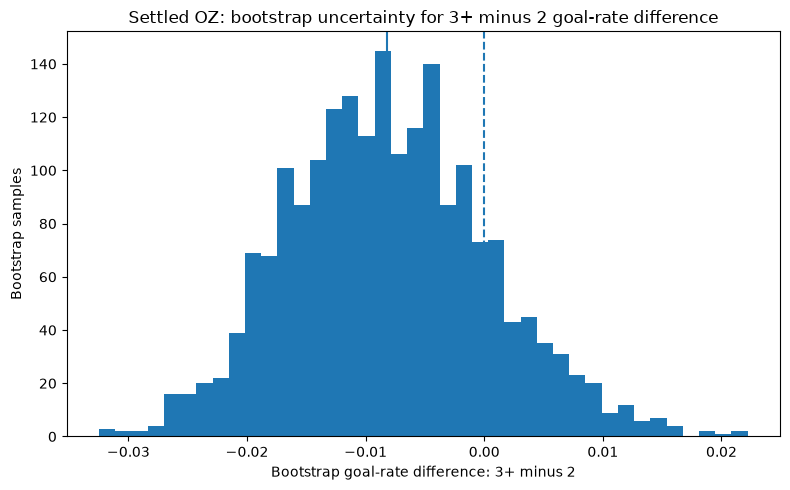

In [37]:
# Plot bootstrap distribution for the raw settled-OZ 3+ minus 2 goal-rate difference

plt.figure(figsize=(8, 5))
plt.hist(bootstrap_diffs, bins=40)
plt.axvline(0, linestyle="--")
plt.axvline(bootstrap_goal_diff_summary["observed_diff_3_plus_minus_2"])
plt.xlabel("Bootstrap goal-rate difference: 3+ minus 2")
plt.ylabel("Bootstrap samples")
plt.title("Settled OZ: bootstrap uncertainty for 3+ minus 2 goal-rate difference")
plt.tight_layout()
plt.show()

## 14. Settled-OZ Model Summary

Summarize the model control check using predicted probabilities rather than raw one-hot coefficients.

The key question is whether `3+` remains below `2` after controlling for basic location, defender, tracking, and first-shot danger variables.

In [38]:
# Build a compact model-control summary focused on 2 vs 3+ predicted goal probability

model_control_summary = settled_model_prediction_comparison.copy()

model_control_summary = model_control_summary.rename(
    columns={
        "2": "predicted_goal_probability_2",
        "3+": "predicted_goal_probability_3_plus",
    }
)

model_control_summary["predicted_goal_probability_2_pct"] = (
    100 * model_control_summary["predicted_goal_probability_2"]
)

model_control_summary["predicted_goal_probability_3_plus_pct"] = (
    100 * model_control_summary["predicted_goal_probability_3_plus"]
)

model_control_summary["predicted_goal_prob_diff_3_plus_minus_2_pct_pts"] = (
    100 * model_control_summary["predicted_goal_prob_diff_3_plus_minus_2"]
)

model_control_summary[
    [
        "model",
        "predicted_goal_probability_2_pct",
        "predicted_goal_probability_3_plus_pct",
        "predicted_goal_prob_diff_3_plus_minus_2_pct_pts",
    ]
]

slot_support_bin,model,predicted_goal_probability_2_pct,predicted_goal_probability_3_plus_pct,predicted_goal_prob_diff_3_plus_minus_2_pct_pts
0,with_first_xg,1.925525,1.257483,-0.668041
1,without_first_xg,2.854919,1.890190,-0.964729


In [39]:
# Build computed control-check notes without hardcoding the conclusion

settled_control_check_notes = {
    "raw_goal_rate_diff_3_plus_minus_2": float(
        settled_control_summary.loc[
            settled_control_summary["check"].eq("overall_2_vs_3_plus"),
            "goal_rate_diff_3_plus_minus_2",
        ].iloc[0]
    ),
    "crowded_slot_goal_rate_diff_3_plus_minus_2": float(
        settled_control_summary.loc[
            settled_control_summary["check"].eq("2_plus_defenders"),
            "goal_rate_diff_3_plus_minus_2",
        ].iloc[0]
    ),
    "closer_distance_goal_rate_diff_3_plus_minus_2": float(
        settled_control_summary.loc[
            settled_control_summary["check"].eq("closer_distance_third"),
            "goal_rate_diff_3_plus_minus_2",
        ].iloc[0]
    ),
    "bootstrap_ci_low_2_5": float(
        bootstrap_goal_diff_summary["bootstrap_ci_low_2_5"]
    ),
    "bootstrap_ci_high_97_5": float(
        bootstrap_goal_diff_summary["bootstrap_ci_high_97_5"]
    ),
    "bootstrap_share_diffs_below_zero": float(
        bootstrap_goal_diff_summary["share_bootstrap_diffs_below_zero"]
    ),
    "model_diff_without_first_xg": float(
        model_control_summary.loc[
            model_control_summary["model"].eq("without_first_xg"),
            "predicted_goal_prob_diff_3_plus_minus_2",
        ].iloc[0]
    ),
    "model_diff_with_first_xg": float(
        model_control_summary.loc[
            model_control_summary["model"].eq("with_first_xg"),
            "predicted_goal_prob_diff_3_plus_minus_2",
        ].iloc[0]
    ),
}

settled_control_check_notes

{'raw_goal_rate_diff_3_plus_minus_2': -0.008211956542262536,
 'crowded_slot_goal_rate_diff_3_plus_minus_2': -0.01115884721383641,
 'closer_distance_goal_rate_diff_3_plus_minus_2': -0.0214447090431703,
 'bootstrap_ci_low_2_5': -0.02359026694712038,
 'bootstrap_ci_high_97_5': 0.009541178736372237,
 'bootstrap_share_diffs_below_zero': 0.8325,
 'model_diff_without_first_xg': -0.00964729017057871,
 'model_diff_with_first_xg': -0.006680410635939212}

## 15. Final Notebook Validation

Run lightweight checks before committing the notebook.

This notebook does not save a new processed dataset.

In [40]:
# Validate the final state of the control-check notebook

final_notebook_validation = {
    "input_rows": len(df),
    "analysis_rows": len(analysis),
    "analysis_unique_chain_ids": analysis["chain_id"].nunique(),
    "analysis_duplicate_chain_ids": analysis.duplicated("chain_id").sum(),
    "behind_blue_line_rows_in_analysis": int(
        analysis["is_behind_offensive_blue_line_origin"].sum()
    ),
    "settled_oz_rows": len(settled_oz),
    "settled_oz_2_vs_3_rows": len(settled_oz_2_vs_3),
    "settled_model_rows": len(settled_model_df),
    "bootstrap_samples": BOOTSTRAP_SAMPLES,
    "model_control_summary_rows": len(model_control_summary),
}

final_notebook_validation

{'input_rows': 48673,
 'analysis_rows': 21536,
 'analysis_unique_chain_ids': 21536,
 'analysis_duplicate_chain_ids': np.int64(0),
 'behind_blue_line_rows_in_analysis': 0,
 'settled_oz_rows': 15387,
 'settled_oz_2_vs_3_rows': 3566,
 'settled_model_rows': 15387,
 'bootstrap_samples': 2000,
 'model_control_summary_rows': 2}

In [41]:
# Assert expected final notebook validation values

expected_final_notebook_validation = {
    "input_rows": 48673,
    "analysis_rows": 21536,
    "analysis_unique_chain_ids": 21536,
    "analysis_duplicate_chain_ids": 0,
    "behind_blue_line_rows_in_analysis": 0,
    "settled_oz_rows": 15387,
    "settled_oz_2_vs_3_rows": 3566,
    "settled_model_rows": 15387,
    "bootstrap_samples": 2000,
    "model_control_summary_rows": 2,
}

for key, expected_value in expected_final_notebook_validation.items():
    actual_value = int(final_notebook_validation[key])
    assert actual_value == expected_value, (
        f"{key}: expected {expected_value}, got {actual_value}"
    )

print("Final notebook validation passed.")

Final notebook validation passed.


**Checkpoint — Notebook 10 Control Result**

The settled-OZ 2-vs-3+ pattern remains directionally consistent across basic control checks, but bootstrap uncertainty crosses zero.

The 3+ bin has slightly more favorable basic location and first-xG characteristics than the 2-attacker bin, but lower raw goal rate.

The lower 3+ goal rate also appears in the crowded-slot subset and in the closer-distance subset.

A simple logistic control model predicts lower goal probability for 3+ than for 2, both with and without first evaluated xG.

This remains observational and should be framed as a directional diagnostic pattern, not a causal estimate or a definitive penalty for 3+ traffic.